<a href="https://colab.research.google.com/github/AjMing/Pattern-EGCI463/blob/main/Week3/Reading_digit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import io

#Read digit from digit.csv
from google.colab import files
uploaded = files.upload()



Saving digit.csv to digit.csv


In [ ]:
import pandas as pd
df = pd.read_csv(io.BytesIO(uploaded["digit.csv"]),header=None)

In [ ]:
df


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


Show First digit

In [ ]:
print(np.reshape(np.array(df.iloc[0,:-1]),[28,28]))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253
  159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252
  252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239
  233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202
   84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 163 252 252 252 25

In [ ]:
import matplotlib.pyplot as plt


Reshape 500x784 --> 10 x 50 x 784
                   digit x Number    x pixel

In [ ]:
digit =np.reshape(np.array(df.iloc[:,:-1]),[10,50,784])

Visualized a digit



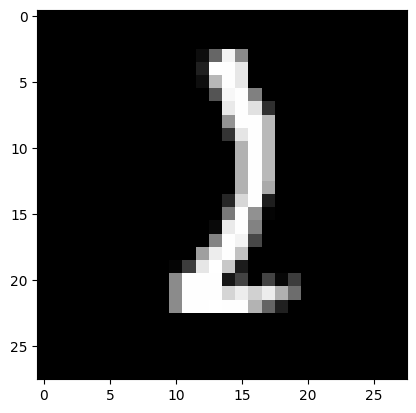

In [ ]:
plt.imshow(np.reshape(digit[2,15,:],[28,28]),cmap='gray')
plt.show()

Try Visualize one of digit 3

In [ ]:
print(digit[0,:,:].shape)

(50, 784)


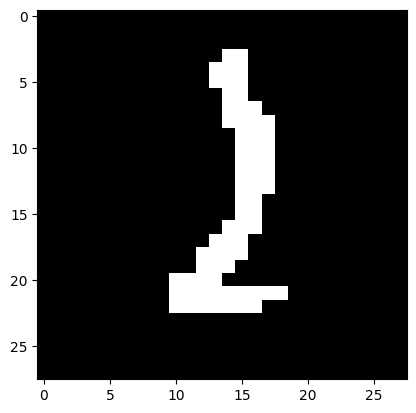

In [ ]:
#show binary
bin_digit=1*(digit>128)
plt.imshow(np.reshape(bin_digit[2,15,:],[28,28]),cmap='gray')
plt.show()

# Create train data (80%/20%)

In [ ]:
from sklearn.model_selection import train_test_split

x = df.iloc[:100, :-1].values
y = df.iloc[:100, -1].values

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

train0, train1 = 1*(X_train[y_train==0] > 128), 1*(X_train[y_train==1] > 128)
test0,  test1  = 1*(X_test[y_test==0] > 128),  1*(X_test[y_test==1] > 128)

numbers = np.stack([train0.mean(axis=0), train1.mean(axis=0)])  # numbers[0]=P(D|0), numbers[1]=P(D|1)

print(numbers.shape)


(2, 784)


In [ ]:
print(numbers[0])


[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.025 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.125 0.25  0.2   0.25  0.3   0.325 0.25  0.075
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.025 0.075 0.1   0.25  0.375 0.575 0.65  0.725
 0.725 0.675 0.5   0.35  0.175 0.05  0.    0.    0.    0.    0.    0.
 0.    0.    0

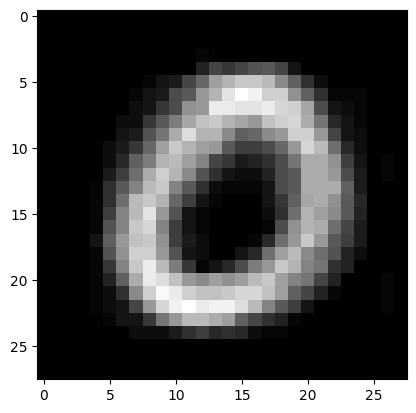

In [ ]:
plt.imshow(np.reshape(numbers[0],[28,28]),cmap='gray')


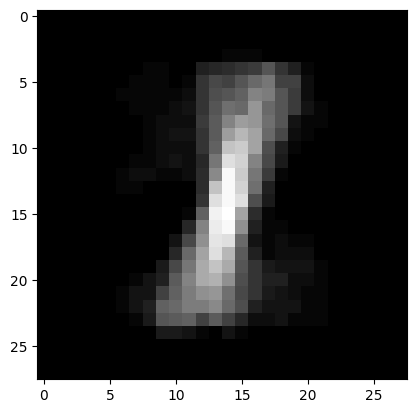

In [ ]:
plt.imshow(np.reshape(numbers[1],[28,28]),cmap='gray')


In [ ]:
print(np.reshape(numbers[1],[28,28]))


[[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.025 0.025 0.025 0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.025 0.025 0.    0.
  0.125 0.15  0.175 0.2   0.225 0.325 0.2   0.125 0.025 0.    0.    0.
  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.025 0.025 0.025 0.    0.025
  0.2   0.275 0.25  0.325 0.4   0.45  0.25  0.25  0.05  0.    0.    0.
  0.    0.

In [ ]:
(1-test0)*(1-numbers[0])


array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [21]:
# p(0|number) = p(digit|0) p(0) /   (p(0|digit) p(0)+ p(1|digit) p(1))
p0 = np.prod(test0*numbers[0]+(1-test0)*(1-numbers[0]),axis=1)*.5 # p(digit|0) p(0)
p1 = np.prod(test0*numbers[1]+(1-test0)*(1-numbers[1]),axis=1)*.5 # p(digit|1) p(1)

prob0=p0/(p0+p1)
prob1=p1/(p0+p1)


/tmp/ipykernel_1515/2378355951.py:5: RuntimeWarning: invalid value encountered in divide
  prob0=p0/(p0+p1)
/tmp/ipykernel_1515/2378355951.py:6: RuntimeWarning: invalid value encountered in divide
  prob1=p1/(p0+p1)


In [22]:
print(np.array([prob0 ,prob1]).T)


[[nan nan]
 [ 1.  0.]
 [nan nan]
 [ 1.  0.]
 [nan nan]
 [nan nan]
 [ 1.  0.]
 [nan nan]
 [ 1.  0.]
 [nan nan]]


In [23]:
p0 = np.prod(test1*numbers[0]+(1-test1)*(1-numbers[0]),axis=1)*.5 # p(digit|0) p(0)
p1 = np.prod(test1*numbers[1]+(1-test1)*(1-numbers[1]),axis=1)*.5 # p(digit|1) p(1)

prob0=p0/(p0+p1)
prob1=p1/(p0+p1)


/tmp/ipykernel_1515/2469727410.py:4: RuntimeWarning: invalid value encountered in divide
  prob0=p0/(p0+p1)
/tmp/ipykernel_1515/2469727410.py:5: RuntimeWarning: invalid value encountered in divide
  prob1=p1/(p0+p1)


In [24]:
print(np.array([prob0 ,prob1]).T)

[[ 0.  1.]
 [nan nan]
 [ 0.  1.]
 [ 0.  1.]
 [ 0.  1.]
 [ 0.  1.]
 [ 0.  1.]
 [ 0.  1.]
 [nan nan]
 [nan nan]]


# Compare to train Data

In [27]:
# p(0|number) = p(digit|0) p(0) /   (p(0|digit) p(0)+ p(1|digit) p(1))
p0 = np.prod(train0*numbers[0]+(1-train0)*(1-numbers[0]),axis=1)*.5 # p(digit|0) p(0)
p1 = np.prod(train0*train0[1]+(1-train0)*(1-numbers[1]),axis=1)*.5 # p(digit|1) p(1)

prob0=p0/(p0+p1)
prob1=p1/(p0+p1)
np.set_printoptions(precision=3,suppress=True)
print(np.array([prob0 ,prob1]).T)

[[1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [29]:
p0 = np.prod(train1*numbers[0]+(1-train1)*(1-numbers[0]),axis=1)*.5 # p(digit|0) p(0)
p1 = np.prod(train1*numbers[1]+(1-train1)*(1-numbers[1]),axis=1)*.5 # p(digit|1) p(1)

prob0=p0/(p0+p1)
prob1=p1/(p0+p1)
np.set_printoptions(precision=3,suppress=True)
print(np.array([prob0 ,prob1]).T)

[[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


#Discussion ? Why 'Nan' Value-->What are they coming from?

#Try with more/different digits

> Add blockquote

